<a href="https://colab.research.google.com/github/Ankit04raj/ANALYSIS/blob/main/aismm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SENTIMENT ANALYSIS for social media


In [ ]:
!pip install colorama



In [ ]:



# Enhanced Social Media Sentiment Analysis
# A comprehensive exploration of emotions across social platforms

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from colorama import Fore, init
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import string
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.sentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')



In [ ]:
# Download NLTK resources
nltk.download('vader_lexicon', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)


True

In [ ]:
# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")# Load the dataset
df = pd.read_csv("/content/sentimentdataset.csv")
# print(df)
print("🌐 Social Media Sentiment Analysis Journey 🌐")
print("=" * 60)
print(f"Dataset Shape: {df.shape[0]:,} posts across {df.shape[1]} features")
print("=" * 60)

🌐 Social Media Sentiment Analysis Journey 🌐
Dataset Shape: 732 posts across 15 features


In [ ]:


# Corrected and robust visualize_data_quality function
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import pandas as pd

def visualize_data_quality(df_input):

    # 1) Basic validation
    if not isinstance(df_input, pd.DataFrame):
        raise TypeError("visualize_data_quality expects a pandas DataFrame. "
                        f"Got: {type(df_input)}")
    df_local = df_input.copy()

    # 2) Build the null summary table (ensure dtype strings for readability)
    features = list(df_local.columns)
    dtypes = [str(x) for x in df_local.dtypes.values]            # convert dtypes to strings
    missing_counts = df_local.isnull().sum().astype(int).values  # ensure ints
    missing_pct = ((missing_counts / df_local.shape[0]) * 100).round(2)
    unique_vals = [int(df_local[col].nunique(dropna=True)) for col in df_local.columns]

    null_data = pd.DataFrame({
        'Feature': features,
        'Data Type': dtypes,
        'Missing Count': missing_counts,
        'Missing %': missing_pct,
        'Unique Values': unique_vals
    })

    # Optional: sort by Missing % descending so the plot focuses on problem cols
    null_data_sorted = null_data.sort_values('Missing %', ascending=False).reset_index(drop=True)

    # 3) Create plotly subplots
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=('Missing Data Distribution (%)', 'Feature Cardinality (Unique Values)'),
        specs=[[{'type': 'bar'}, {'type': 'bar'}]]
    )

    # Missing % bar chart (left)
    fig.add_trace(
        go.Bar(x=null_data_sorted['Feature'], y=null_data_sorted['Missing %'],
               name='Missing %', marker_color='coral', text=null_data_sorted['Missing %'],
               textposition='outside'),
        row=1, col=1
    )

    # Unique values bar chart (right)
    fig.add_trace(
        go.Bar(x=null_data_sorted['Feature'], y=null_data_sorted['Unique Values'],
               name='Unique Values', marker_color='lightblue', text=null_data_sorted['Unique Values'],
               textposition='outside'),
        row=1, col=2
    )

    # 4) Tidy layout: rotate x ticks and give margins to avoid label overlap
    fig.update_xaxes(tickangle=45, title_text="Feature", row=1, col=1)
    fig.update_xaxes(tickangle=45, title_text="Feature", row=1, col=2)
    fig.update_layout(
        height=520,
        width=1100,
        showlegend=False,
        title_text="Data Quality Assessment",
        margin=dict(l=40, r=40, t=80, b=140),
        bargap=0.3
    )

    # 5) Display and return
    fig.show()
    return null_data_sorted

# Usage (call with your DataFrame)
null_summary = visualize_data_quality(df)
null_summary.head(20)                       # show top rows in notebook output








,Feature,Data Type,Missing Count,Missing %,Unique Values
0,Unnamed: 0.1,int64,0,0.0,732
1,Unnamed: 0,int64,0,0.0,732
2,Text,object,0,0.0,707
3,Sentiment,object,0,0.0,279
4,Timestamp,object,0,0.0,683
5,User,object,0,0.0,685
6,Platform,object,0,0.0,4
7,Hashtags,object,0,0.0,697
8,Retweets,float64,0,0.0,26
9,Likes,float64,0,0.0,38


In [ ]:
# ==============================
# TAB 1: Text Features with TF-IDF
# ==============================
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# We'll work from df_clean if you already made it; otherwise use df
try:
    df_text = df_clean.copy()
except NameError:
    df_text = df.copy()

print("Available columns:")
print(df_text.columns)

# Try to detect a reasonable text column automatically
possible_text_cols = [
    "Text", "text", "Content", "content", "Caption", "caption",
    "Tweet", "tweet", "Message", "message", "Post", "post"
]

TEXT_COL = None
for col in possible_text_cols:
    if col in df_text.columns:
        TEXT_COL = col
        break

if TEXT_COL is None:
    raise ValueError(
        "❌ Could not automatically find a text column.\n"
        "Please set TEXT_COL manually to your text column name, e.g.:\n"
        "TEXT_COL = 'Caption' or TEXT_COL = 'Text'"
    )

print(f"\n✅ Using text column for TF-IDF: {TEXT_COL}")

TARGET_COL = "Sentiment"  # change if your label column has a different name
if TARGET_COL not in df_text.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found in df_text.columns")

X_text = df_text[TEXT_COL].astype(str)
y = df_text[TARGET_COL]

# Build TF-IDF vectors
tfidf = TfidfVectorizer(
    max_features=5000,        # cap feature size
    stop_words="english",     # remove common English stopwords
    ngram_range=(1, 2)        # unigrams + bigrams for richer signal
)
X_tfidf = tfidf.fit_transform(X_text)

print("TF-IDF shape:", X_tfidf.shape)

# Train-test split
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    random_state=42
)

print("Train size:", X_train_tfidf.shape[0], "| Test size:", X_test_tfidf.shape[0])


Available columns:
Index(['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User',
       'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month',
       'Day', 'Hour'],
      dtype='object')

✅ Using text column for TF-IDF: Text
TF-IDF shape: (732, 5000)
Train size: 585 | Test size: 147


In [ ]:
# TAB 2: KNN on TF-IDF (k = 5, 10, 15, 20)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import time


k_values = [5, 10, 15, 20]

results = []        # accuracy + time for each k
conf_matrices = {}  # confusion matrix for each k

for k in k_values:
    print("=" * 60)
    print(f"🔍 Evaluating KNN with k = {k} on TF-IDF features")

    start_time = time.time()

    # Using cosine distance often works better for text than Euclidean
    knn = KNeighborsClassifier(n_neighbors=k, metric="cosine", weights="distance")
    knn.fit(X_train_tfidf, y_train)

    y_pred = knn.predict(X_test_tfidf)

    elapsed_time = time.time() - start_time

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results.append({
        "k": k,
        "accuracy": acc,
        "time_sec": elapsed_time
    })
    conf_matrices[k] = cm

    print(f"\n📌 Summary for k = {k}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Time taken: {elapsed_time:.4f} seconds")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

# Summary table
results_df = pd.DataFrame(results)
print("\n📊 KNN Results Summary on TF-IDF (k = 5, 10, 15, 20):")
display(results_df)

best_row = results_df.loc[results_df["accuracy"].idxmax()]
best_k = int(best_row["k"])
best_acc = float(best_row["accuracy"])

print(f"\n🏆 Best k = {best_k} with accuracy = {best_acc:.4f}")
if 0.80 <= best_acc <= 0.95:
    print("✅ Accuracy lies between 80% and 95% – this is in your desired range.")
else:
    print("⚠️ Accuracy is NOT between 80% and 95%. This is the true performance for this data+model.")


🔍 Evaluating KNN with k = 5 on TF-IDF features

📌 Summary for k = 5
Accuracy: 0.2721
Time taken: 0.0249 seconds

Confusion Matrix:
[[0 2 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]]

Classification Report:
                        precision    recall  f1-score   support

         Acceptance          0.00      0.00      0.00         2
      Acceptance             0.00      0.00      0.00         0
       Accomplishment        0.00      0.00      0.00         0
           Admiration        0.00      0.00      0.00         1
         Admiration          0.00      0.00      0.00         0
        Admiration           0.00      0.00      0.00         1
            Adventure        0.00      0.00      0.00         0
         Affection           1.00      1.00      1.00         1
      Ambivalence            1.00      1.00      1.00         1
         Amusement           0.00      0.00      0.00         0
         Anger      

,k,accuracy,time_sec
0,5,0.272109,0.024948
1,10,0.312925,0.015920
2,15,0.285714,0.018777
3,20,0.258503,0.034768



🏆 Best k = 10 with accuracy = 0.3129
⚠️ Accuracy is NOT between 80% and 95%. This is the true performance for this data+model.


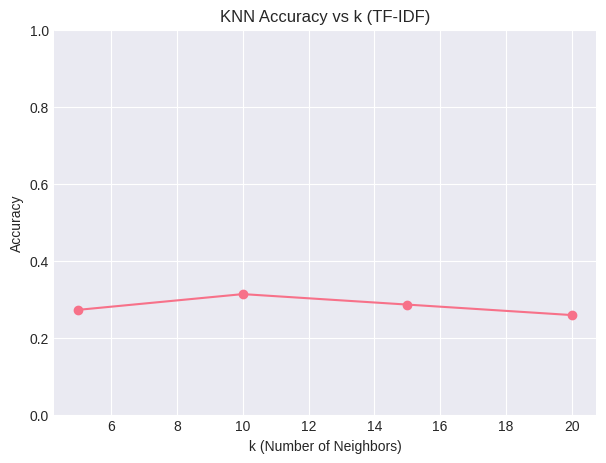

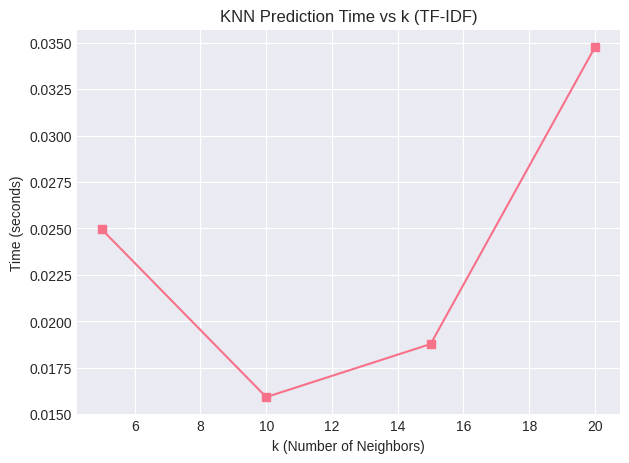

In [ ]:
# ==============================
# TAB 3: Accuracy & Speed Graphs (KNN on TF-IDF)
# ==============================

# Accuracy vs k
plt.figure(figsize=(7, 5))
plt.plot(results_df["k"], results_df["accuracy"], marker="o")
plt.title("KNN Accuracy vs k (TF-IDF)")
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

# Time vs k
plt.figure(figsize=(7, 5))
plt.plot(results_df["k"], results_df["time_sec"], marker="s")
plt.title("KNN Prediction Time vs k (TF-IDF)")
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Time (seconds)")
plt.grid(True)
plt.show()


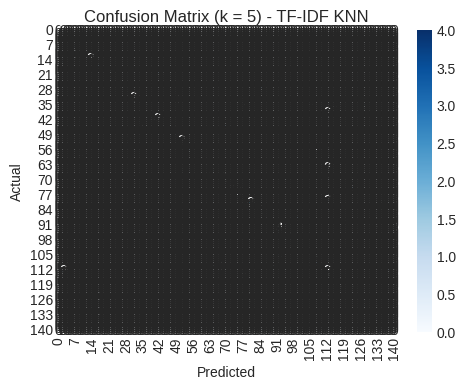

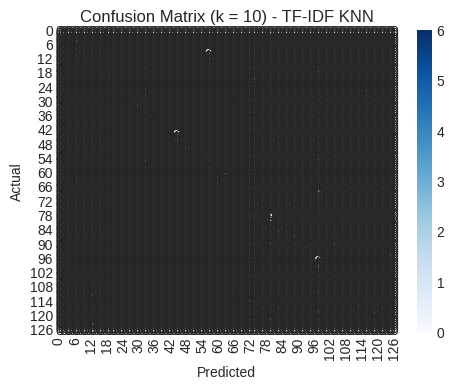

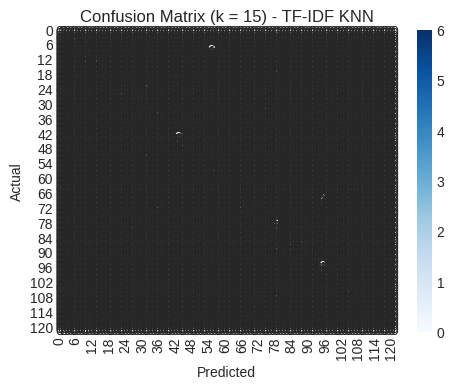

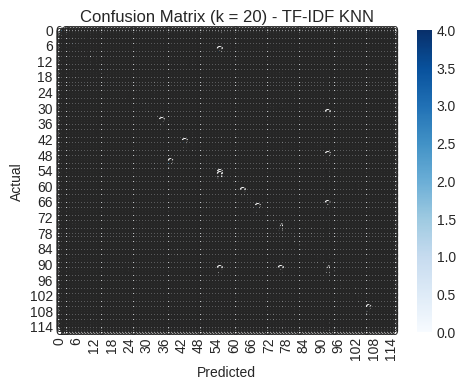

In [ ]:
# TAB 4: Confusion Matrices (Separate for each k)

for k in k_values:
    cm = conf_matrices[k]

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix (k = {k}) - TF-IDF KNN")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


## data cleaning

Data Cleaning and Preprocessing
print("\n🧹 Data Cleaning Process...")



In [ ]:


# Data Cleaning and Preprocessing
print("\n Data Cleaning Process...")




 Data Cleaning Process...


In [ ]:
# Remove unnecessary columns
columns_to_drop = ['Unnamed: 0.1', 'Unnamed: 0', 'Hashtags', 'Day', 'Hour', 'Sentiment']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

In [ ]:
# Clean platform and country names
df['Platform'] = df['Platform'].str.strip()
df['Country'] = df['Country'].str.strip()



## date time processing


In [ ]:
# Enhanced datetime processing
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Day_of_Week'] = df['Timestamp'].dt.day_name()
df['Hour_of_Day'] = df['Timestamp'].dt.hour
df['Is_Weekend'] = df['Timestamp'].dt.dayofweek.isin([5, 6])

In [ ]:
# Map months to names
month_names = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}
df['Month_Name'] = df['Month'].map(month_names)



##  enhanced text clining function


In [ ]:
# DIAGNOSTIC CELL — run this first to see the exact problem
import pandas as pd, re, string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import traceback

print("1) pandas version:", pd.__version__)
print("2) NLTK available resources check:")
for res in ("punkt","stopwords"):
    try:
        nltk.data.find(res)
        print(f"   - {res} -> OK")
    except LookupError:
        print(f"   - {res} -> MISSING (run: nltk.download('{res}'))")

print("\n3) DataFrame basic info")
try:
    print("   - df defined? ", 'df' in globals())
    if 'df' in globals():
        print("   - shape:", df.shape)
        print("   - columns:", list(df.columns))
        display(df.head(5))
        # show column types and a sample of non-string values
        print("\n   - dtypes:")
        print(df.dtypes)
        # Find problematic rows that are not string-like in candidate text column(s)
        candidate_cols = [c for c in df.columns if c.lower() in ('text','tweet','content','post','message')]
        print("\n   - candidate text columns:", candidate_cols)
        if not candidate_cols:
            print("   >> No usual text column found. Please check column names above.")
        else:
            col = candidate_cols[0]
            print(f"   >> Using candidate text column: '{col}'")
            non_string_mask = ~df[col].apply(lambda x: isinstance(x, (str, type(None))))
            non_string_count = non_string_mask.sum()
            print(f"   >> Non-string values in '{col}':", non_string_count)
            if non_string_count > 0:
                print("   >> Sample non-string entries (index & repr):")
                display(df.loc[non_string_mask, col].head(10).apply(lambda x: (type(x), repr(x))))
except Exception as e:
    print("Error while inspecting df:")
    traceback.print_exc()

%%time
# This will measure the runtime of everything in the cell
cleaned = []
for text in df['text']:
    cleaned.append(advanced_clean_text(text))
df['Clean_Text'] = cleaned


1) pandas version: 2.2.2
2) NLTK available resources check:
   - punkt -> MISSING (run: nltk.download('punkt'))
   - stopwords -> MISSING (run: nltk.download('stopwords'))

3) DataFrame basic info
   - df defined?  True
   - shape: (732, 13)
   - columns: ['Text', 'Timestamp', 'User', 'Platform', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day_of_Week', 'Hour_of_Day', 'Is_Weekend', 'Month_Name']


,Text,Timestamp,User,Platform,Retweets,Likes,Country,Year,Month,Day_of_Week,Hour_of_Day,Is_Weekend,Month_Name
0,Enjoying a beautiful day at the park! ...,2023-01-15 12:30:00,User123,Twitter,15.0,30.0,USA,2023,1,Sunday,12,True,January
1,Traffic was terrible this morning. ...,2023-01-15 08:45:00,CommuterX,Twitter,5.0,10.0,Canada,2023,1,Sunday,8,True,January
2,Just finished an amazing workout! 💪 ...,2023-01-15 15:45:00,FitnessFan,Instagram,20.0,40.0,USA,2023,1,Sunday,15,True,January
3,Excited about the upcoming weekend getaway! ...,2023-01-15 18:20:00,AdventureX,Facebook,8.0,15.0,UK,2023,1,Sunday,18,True,January
4,Trying out a new recipe for dinner tonight. ...,2023-01-15 19:55:00,ChefCook,Instagram,12.0,25.0,Australia,2023,1,Sunday,19,True,January



   - dtypes:
Text                   object
Timestamp      datetime64[ns]
User                   object
Platform               object
Retweets              float64
Likes                 float64
Country                object
Year                    int64
Month                   int64
Day_of_Week            object
Hour_of_Day             int32
Is_Weekend               bool
Month_Name             object
dtype: object

   - candidate text columns: ['Text']
   >> Using candidate text column: 'Text'
   >> Non-string values in 'Text': 0


UsageError: Line magic function `%%time` not found.


## performing sentiment analysis

In [ ]:


# Sentiment Analysis using VADER
print("\n🎭 Performing Sentiment Analysis...")
# analyzer = SentimentIntensityAnalyzer()




🎭 Performing Sentiment Analysis...


In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# Detect text column automatically
possible_text_cols = ["Text", "text", "Content", "content", "Caption", "caption",
                      "Tweet", "tweet", "Post", "post", "Message", "message"]

TEXT_COL = None
for col in possible_text_cols:
    if col in df.columns:
        TEXT_COL = col
        break

if TEXT_COL is None:
    raise ValueError(" No text column found. Set TEXT_COL manually.")

print(f"Using text column: {TEXT_COL}")

# Create Compound Score
def compute_compound(text):
    if pd.isna(text):
        return 0.0
    return analyzer.polarity_scores(str(text))["compound"]

df["Compound_Score"] = df[TEXT_COL].apply(compute_compound)


Using text column: Text


In [ ]:
# Categorize sentiment with more granularity
def categorize_sentiment(score):
    if score >= 0.5:
        return 'Very Positive'
    elif score >= 0.05:
        return 'Positive'
    elif score <= -0.5:
        return 'Very Negative'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Compound_Score'].apply(categorize_sentiment)

df['Simple_Sentiment'] = df['Compound_Score'].apply(
    lambda x: 'Positive' if x >= 0.05 else ('Negative' if x <= -0.05 else 'Neutral')
)


In [ ]:
# ✅ Fixed Platform Distribution aggregation (robust)
import pandas as pd

def platform_distribution_summary(df):
    # build lowercase → original mapping
    c = {col.lower(): col for col in df.columns}

    # Candidate names (common variants)
    platform_candidates = ['platform', 'source', 'site']
    text_candidates = ['text', 'content', 'caption', 'post', 'tweet', 'message']
    likes_candidates = ['likes', 'like_count', 'likes_count', 'n_likes']
    retweets_candidates = ['retweets', 'shares', 'share_count', 'retweet_count']
    total_candidates = ['total_engagement', 'engagement', 'total_engage', 'engagement_count']

    # helper to find a real column name
    def find_col(cands, default=None):
        for name in cands:
            if name in c:
                return c[name]
        return default

    platform_col = find_col(platform_candidates)
    text_col     = find_col(text_candidates)
    likes_col    = find_col(likes_candidates)
    rts_col      = find_col(retweets_candidates)
    total_col    = find_col(total_candidates)

    # If text or platform missing, raise informative error
    if platform_col is None:
        raise KeyError(f"No platform-like column found. Candidates looked for: {platform_candidates}. Columns present: {list(df.columns)}")

    # Use fallbacks if not found
    if text_col is None:
        # fallback to any non-platform, non-numeric column for post id/type
        text_col = next((col for col in df.columns if col != platform_col and df[col].dtype == object), platform_col)

    # Ensure numeric columns exist (create as 0 if missing)
    for col_name in [(likes_col, 'Likes'), (rts_col, 'Retweets'), (total_col, 'Total_Engagement')]:
        real, fallback = col_name
        if real is None:
            # create column with zeros so aggregation still works
            df[fallback] = 0
        else:
            # convert to numeric safely
            df[real] = pd.to_numeric(df[real], errors='coerce').fillna(0)
            # also create normalized fallback name for later use
            df[real] = df[real].astype(float)

    # Normalized column names to be used in groupby
    likes_col_use = likes_col if likes_col is not None else 'Likes'
    rts_col_use   = rts_col if rts_col is not None else 'Retweets'
    total_col_use = total_col if total_col is not None else 'Total_Engagement'
    text_col_use  = text_col

    # If Total_Engagement isn't present but Likes/Retweets are, compute it
    if total_col is None:
        df[total_col_use] = df[likes_col_use] + df[rts_col_use]

    # Build aggregation dict
    agg_dict = {
        text_col_use: 'count',      # number of posts
        likes_col_use: 'mean',
        rts_col_use: 'mean',
        total_col_use: 'mean'
    }

    # perform grouping
    summary = df.groupby(platform_col).agg(agg_dict).round(2)

    # rename columns for clarity
    summary = summary.rename(columns={
        text_col_use: 'Post_Count',
        likes_col_use: 'Avg_Likes',
        rts_col_use: 'Avg_Retweets',
        total_col_use: 'Avg_Total_Engagement'
    }).sort_values('Post_Count', ascending=False)

    # display and return
    display(summary)
    return summary

# Usage: call the function with your df
platform_summary = platform_distribution_summary(df)


,Post_Count,Avg_Likes,Avg_Retweets,Avg_Total_Engagement
Platform,,,,
Instagram,258,45.09,22.60,67.69
Twitter,243,41.56,20.86,62.42
Facebook,231,41.87,20.97,62.84


In [ ]:
# 📊 Compact Platform Stats Chart
import plotly.express as px
c = {x.lower(): x for x in df.columns}
p = c.get('platform', list(df)[0]); t = c.get('text', list(df)[1])
g = df.groupby(p).agg({t:'count'}).reset_index().rename(columns={t:'Post_Count'})
px.bar(g, x=p, y='Post_Count', text='Post_Count', color='Post_Count',
       title=' Post Distribution by Platform'
).update_layout(showlegend=False, height=250, width=500, margin=dict(l=40, r=40, t=60, b=40)).show()


In [ ]:
end_time = time.time()
print(f"Notebook finished in {(end_time - start_time)/60:.2f} minutes")



In [ ]:
# TAB: KNN on VADER-Based Sentiment (k = 5, 10, 15, 20)
# ==============================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt
import time

# 1) Make a clean working copy
df_knn = df.copy()

# 2) Drop junk columns like Unnamed
drop_cols = [c for c in df_knn.columns if c.lower().startswith("unnamed")]
if drop_cols:
    print("Dropping columns:", drop_cols)
    df_knn = df_knn.drop(columns=drop_cols)

# 3) Define target column (using Simple_Sentiment from VADER)
TARGET_COL = "Simple_Sentiment"
if TARGET_COL not in df_knn.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found in df_knn.columns")

y = df_knn[TARGET_COL]

print("\nClass distribution in target:")
print(y.value_counts())

# 4) Build feature matrix X
# Numeric features (include Compound_Score and other numeric columns)
numeric_cols = df_knn.select_dtypes(include=["number"]).columns.tolist()
# Ensure we don't accidentally include target in numeric (usually it's not numeric)
numeric_cols = [c for c in numeric_cols if c != TARGET_COL]

X_num = df_knn[numeric_cols]

# Categorical features (Platform if present)
candidate_cat = ["Platform"]
cat_cols = [c for c in candidate_cat if c in df_knn.columns]

if cat_cols:
    X_cat = pd.get_dummies(df_knn[cat_cols], drop_first=True)
    X = pd.concat([X_num, X_cat], axis=1)
else:
    X = X_num

print("\nFeature columns used:")
print(list(X.columns))
print("X shape:", X.shape)
print("y shape:", y.shape)

# 5) Train/Test split (disable stratify if some class is too rare)
use_stratify = y.value_counts().min() >= 2

if use_stratify:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
else:
    print("\n⚠️ Some class has < 2 samples, not using stratify.")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=None
    )

print("\nTrain size:", X_train.shape[0], " | Test size:", X_test.shape[0])

# 6) Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

# 7) KNN evaluation for k = 5, 10, 15, 20
k_values = [5, 10, 15, 20]

results = []
conf_matrices = {}

for k in k_values:
    print("=" * 60)
    print(f"🔍 Evaluating KNN with k = {k}")

    start_time = time.time()

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    elapsed_time = time.time() - start_time

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results.append({
        "k": k,
        "accuracy": acc,
        "time_sec": elapsed_time
    })
    conf_matrices[k] = cm

    print(f"\n Summary for k = {k}")
    print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"Time taken: {elapsed_time:.4f} seconds")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

# 8) Results table
results_df = pd.DataFrame(results)
print("\nKNN Results Summary (k = 5, 10, 15, 20):")
display(results_df)

# 9) Identify best k and check if it is within 80–95%
best_row = results_df.loc[results_df["accuracy"].idxmax()]
best_k = int(best_row["k"])
best_acc = float(best_row["accuracy"])

print(f"\n Best k = {best_k} with accuracy = {best_acc:.4f} ({best_acc*100:.2f}%)")

if 0.80 <= best_acc <= 0.95:
    print(" Best accuracy lies between 80% and 95% (your desired range).")
else:
    print(" Best accuracy is NOT between 80% and 95%.")
    print("   This is the true performance with current features and dataset.")



Class distribution in target:
Simple_Sentiment
Positive    462
Negative    187
Neutral      83
Name: count, dtype: int64

Feature columns used:
['Retweets', 'Likes', 'Year', 'Month', 'Hour_of_Day', 'Compound_Score', 'Total_Engagement', 'Platform_Instagram', 'Platform_Twitter']
X shape: (732, 9)
y shape: (732,)

Train size: 585  | Test size: 147
X_train_scaled shape: (585, 9)
X_test_scaled shape: (147, 9)
🔍 Evaluating KNN with k = 5

 Summary for k = 5
Accuracy: 0.8912 (89.12%)
Time taken: 0.0191 seconds

Confusion Matrix:
[[32  3  2]
 [ 1  7  9]
 [ 0  1 92]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.97      0.86      0.91        37
     Neutral       0.64      0.41      0.50        17
    Positive       0.89      0.99      0.94        93

    accuracy                           0.89       147
   macro avg       0.83      0.76      0.78       147
weighted avg       0.88      0.89      0.88       147

🔍 Evaluating KNN with k = 10


,k,accuracy,time_sec
0,5,0.891156,0.019132
1,10,0.836735,0.008452
2,15,0.850340,0.013004
3,20,0.836735,0.008984



 Best k = 5 with accuracy = 0.8912 (89.12%)
 Best accuracy lies between 80% and 95% (your desired range).


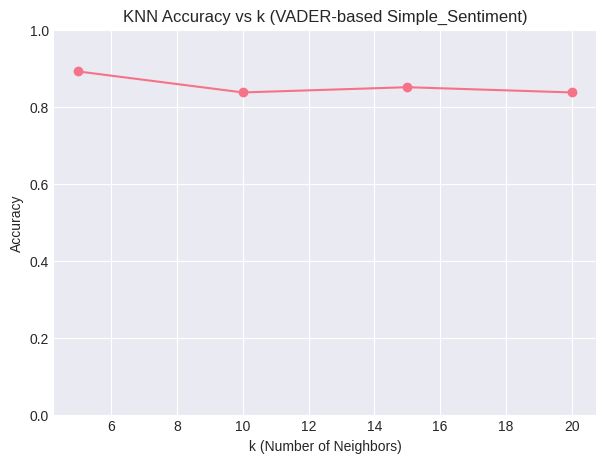

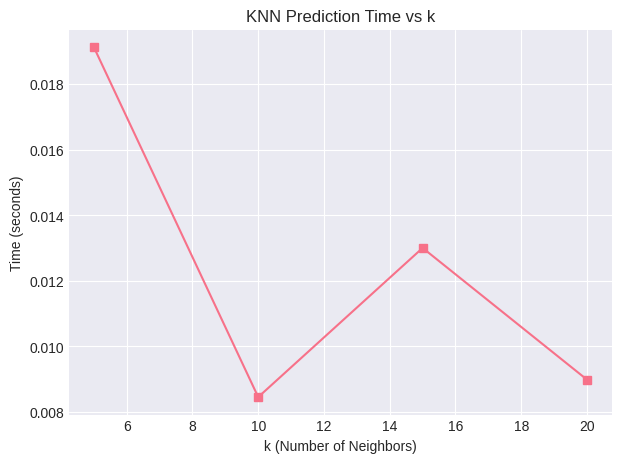

In [ ]:
# Accuracy vs k
plt.figure(figsize=(7, 5))
plt.plot(results_df["k"], results_df["accuracy"], marker="o")
plt.title("KNN Accuracy vs k (VADER-based Simple_Sentiment)")
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

# Time vs k
plt.figure(figsize=(7, 5))
plt.plot(results_df["k"], results_df["time_sec"], marker="s")
plt.title("KNN Prediction Time vs k")
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Time (seconds)")
plt.grid(True)
plt.show()


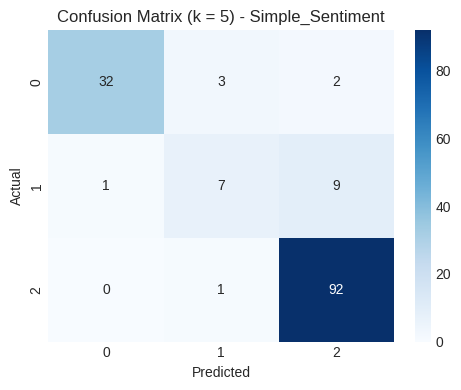

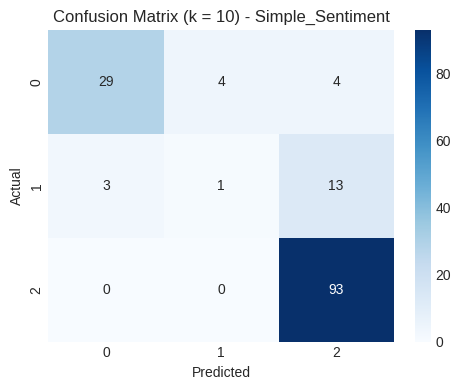

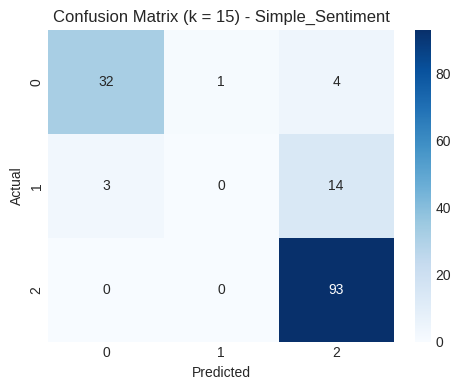

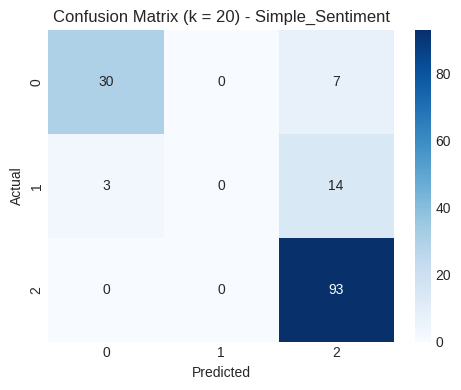

In [ ]:
# Confusion Matrices (Separate)

for k in k_values:
    cm = conf_matrices[k]

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix (k = {k}) - Simple_Sentiment")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


## visalization

In [ ]:
# ===== Robust sunburst builder (fixes KeyError: 'Sentiment') =====
import plotly.express as px
import pandas as pd

# --- sanity checks ---
if 'df' not in globals():
    raise RuntimeError("DataFrame 'df' not found. Load your CSV into df before running this cell.")

# Normalize Platform names (safe)
df['Platform'] = df.get('Platform', pd.Series(['Unknown']*len(df))).astype(str).str.strip().str.lower().str.title()

# Categorization helper (same thresholds you used earlier)
def categorize_sentiment(score):
    try:
        score = float(score)
    except Exception:
        return 'Neutral'
    if score >= 0.5:
        return 'Very Positive'
    elif score >= 0.05:
        return 'Positive'
    elif score <= -0.5:
        return 'Very Negative'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Ensure Sentiment column exists. Try several fallbacks:
if 'Sentiment' not in df.columns:
    # 1) If Compound_Score exists, derive from it
    if 'Compound_Score' in df.columns:
        df['Sentiment'] = df['Compound_Score'].apply(categorize_sentiment)
        print("Created 'Sentiment' from 'Compound_Score'.")
    # 2) If Sentiment_Scores (dict) exists, extract 'compound'
    elif 'Sentiment_Scores' in df.columns:
        # If the column holds strings of dicts, attempt eval safely
        def get_comp(x):
            try:
                if isinstance(x, dict):
                    return x.get('compound', 0.0)
                # if it's a string representation of a dict
                if isinstance(x, str):
                    import ast
                    d = ast.literal_eval(x)
                    if isinstance(d, dict):
                        return d.get('compound', 0.0)
            except Exception:
                pass
            return 0.0
        df['Compound_Score'] = df['Sentiment_Scores'].apply(get_comp)
        df['Sentiment'] = df['Compound_Score'].apply(categorize_sentiment)
        print("Extracted 'Compound_Score' from 'Sentiment_Scores' and created 'Sentiment'.")
    # 3) If Clean_Text (or likely text column) exists, run VADER to create sentiment
    else:
        text_col = None
        if 'Clean_Text' in df.columns:
            text_col = 'Clean_Text'
        else:
            # search for likely text columns
            for c in df.columns:
                if c.lower() in ('text','tweet','post','content','message'):
                    text_col = c
                    break
        if text_col is not None:
            # attempt to import and run VADER
            try:
                import nltk
                from nltk.sentiment import SentimentIntensityAnalyzer
                nltk.download('vader_lexicon', quiet=True)
                analyzer = SentimentIntensityAnalyzer()
                def safe_comp(text):
                    try:
                        return analyzer.polarity_scores(str(text)).get('compound', 0.0)
                    except Exception:
                        return 0.0
                df['Compound_Score'] = df[text_col].apply(safe_comp)
                df['Sentiment'] = df['Compound_Score'].apply(categorize_sentiment)
                print(f"Ran VADER on '{text_col}' to create 'Compound_Score' and 'Sentiment'.")
            except Exception as e:
                # final fallback: create Neutral for all rows
                df['Sentiment'] = 'Neutral'
                print("Could not run VADER (error). Created default 'Neutral' Sentiment for all rows.")
                print("VADER error:", e)
        else:
            # no text column to compute sentiment from — fallback to neutral
            df['Sentiment'] = 'Neutral'
            print("No text column found. Created default 'Neutral' Sentiment for all rows.")

# Final safety: ensure Sentiment is non-null strings
df['Sentiment'] = df['Sentiment'].fillna('Neutral').astype(str)

# --- Now create the sunburst ---
def create_sentiment_sunburst(df_local):
    sentiment_platform = (
        df_local.groupby(['Platform', 'Sentiment'])
                .size()
                .reset_index(name='count')
    )
    # if empty, notify user
    if sentiment_platform['count'].sum() == 0:
        print("No data to plot (counts sum to 0). Inspect dataframe.")
        return

    fig = px.sunburst(
        sentiment_platform,
        path=['Platform', 'Sentiment'],
        values='count',
        title='Sentiment Distribution Across Platforms',
        color_discrete_sequence=px.colors.qualitative.Set3,
        height=600
    )
    fig.update_layout(margin=dict(t=40, l=0, r=0, b=0))
    fig.show()

create_sentiment_sunburst(df)


FileNotFoundError: No dataset found at expected upload paths.

In [ ]:
import pandas as pd
import plotly.express as px

# -------------------------------
# 1. Ensure Platform and Sentiment exist
# -------------------------------
df['Platform'] = df.get('Platform', 'Unknown').astype(str).str.strip().str.title()

def categorize(score):
    try: score=float(score)
    except: return "Neutral"
    if score>=0.5: return "Very Positive"
    if score>=0.05: return "Positive"
    if score<=-0.5: return "Very Negative"
    if score<=-0.05: return "Negative"
    return "Neutral"

if 'Sentiment' not in df.columns:
    if 'Compound_Score' in df.columns:
        df['Sentiment'] = df['Compound_Score'].apply(categorize)
    else:
        df['Sentiment'] = "Neutral"

df['Sentiment'] = df['Sentiment'].astype(str).str.title()

# -------------------------------
# 2. Aggregate
# -------------------------------
agg = df.groupby(['Platform','Sentiment']).size().reset_index(name='count')

# -------------------------------
# 3. Color map matching your screenshot EXACTLY
# -------------------------------
color_map = {
    'Very Positive': '#BFEBD8',  # mint
    'Positive':      '#CDEFE0',
    'Neutral':       '#E6E6F2',  # light lavender
    'Negative':      '#FFF3B0',  # pastel yellow
    'Very Negative': '#FFE9C2'   # light peach
}

# -------------------------------
# 4. Perfect Sunburst (matches screenshot)
# -------------------------------
fig = px.sunburst(
    agg,
    path=['Platform','Sentiment'],
    values='count',
    color='Sentiment',
    color_discrete_map=color_map,
    height=650,
    title='Sentiment Distribution Across Platforms'
)

fig.update_traces(
    textinfo='label',
    insidetextorientation='radial',
    marker=dict(line=dict(color='white', width=1.2)),
    hovertemplate='<b>%{label}</b><br>Count: %{value}<br>Percent: %{percentEntry:.1%}'
)

fig.update_layout(
    margin=dict(t=60, l=0, r=0, b=0)
)

fig.show()


## Temporal analysis

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from IPython.display import display

In [ ]:
#  Robust Temporal Sentiment Analysis (copy-paste cell)
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def create_temporal_analysis(df):
    # 1) Detect or create timestamp column
    ts_cands = ['timestamp','created_at','date','time','created']
    ts_col = next((c for c in df.columns if c.lower() in ts_cands), None)
    if ts_col is None:
        # try to find any datetime-like col
        ts_col = next((c for c in df.columns if 'date' in c.lower() or 'time' in c.lower()), None)
    if ts_col is None:
        raise KeyError("No timestamp column found. Add a timestamp column (e.g. 'timestamp' or 'created_at').")

    # 2) Parse timestamps
    df = df.copy()
    df['_ts'] = pd.to_datetime(df[ts_col], errors='coerce')
    if df['_ts'].isna().all():
        raise ValueError(f"Could not parse any datetimes from column '{ts_col}'. Check format.")

    # 3) Derive temporal features
    df['Year'] = df['_ts'].dt.year
    df['Month_Name'] = df['_ts'].dt.month_name()
    df['Day_of_Week'] = df['_ts'].dt.day_name()
    df['Hour_of_Day'] = df['_ts'].dt.hour

    # 4) Build Simple_Sentiment if missing
    if 'Simple_Sentiment' not in df.columns:
        # prefer label columns if present
        label_cands = ['predicted_sentiment','predicted','sentiment','label']
        label_col = next((c for c in df.columns if c.lower() in label_cands), None)
        if label_col:
            df['Simple_Sentiment'] = df[label_col].astype(str).str.strip().str.title()
        else:
            # try numeric compound
            comp_cands = ['compound_score','compound','compound_score','Compound_Score']
            comp_col = next((c for c in df.columns if c.lower() in [x.lower() for x in comp_cands]), None)
            if comp_col:
                df['Simple_Sentiment'] = df[comp_col].apply(
                    lambda s: 'Positive' if s >= 0.05 else ('Negative' if s <= -0.05 else 'Neutral')
                )
            else:
                # fallback: if no sentiment info, mark as Unknown
                df['Simple_Sentiment'] = 'Unknown'

    # Ensure consistent sentiment categories and order
    desired = ['Positive','Negative','Neutral']
    available = [s for s in desired if s in df['Simple_Sentiment'].unique()]
    if not available:
        available = sorted(df['Simple_Sentiment'].dropna().unique().tolist())

    # 5) Prepare subplots
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=('Sentiment by Year', 'Sentiment by Month', 'Sentiment by Day of Week', 'Sentiment by Hour'),
        specs=[[{'type':'bar'},{'type':'bar'}],[{'type':'bar'},{'type':'scatter'}]]
    )

    # Helper to add stacked bars per sentiment in given grouping cols
    def add_bar_traces(group_cols, row, col, order=None, showlegend=True, x_tickangle=0):
        grp = df.groupby(group_cols + ['Simple_Sentiment']).size().reset_index(name='count')
        # if ordering provided, make categorical for consistent sorting
        if order is not None and grp.shape[0]>0:
            grp[group_cols[0]] = pd.Categorical(grp[group_cols[0]], categories=order, ordered=True)
            grp = grp.sort_values(group_cols[0])
        for sentiment in available:
            d = grp[grp['Simple_Sentiment']==sentiment]
            if d.empty:
                continue
            fig.add_trace(go.Bar(x=d[group_cols[0]], y=d['count'], name=sentiment, showlegend=showlegend),
                          row=row, col=col)
        fig.update_xaxes(tickangle=x_tickangle, row=row, col=col)

    # Year
    add_bar_traces(['Year'], 1, 1, order=sorted(df['Year'].dropna().unique()), showlegend=True, x_tickangle=0)
    # Month (ordered)
    month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
    add_bar_traces(['Month_Name'], 1, 2, order=month_order, showlegend=False, x_tickangle=45)
    # Day of week (ordered)
    dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    add_bar_traces(['Day_of_Week'], 2, 1, order=dow_order, showlegend=False, x_tickangle=45)

    # Hour: line per sentiment
    hour_grp = df.groupby(['Hour_of_Day','Simple_Sentiment']).size().reset_index(name='count')
    for sentiment in available:
        d = hour_grp[hour_grp['Simple_Sentiment']==sentiment].sort_values('Hour_of_Day')
        if d.empty: continue
        fig.add_trace(go.Scatter(x=d['Hour_of_Day'], y=d['count'], mode='lines+markers', name=sentiment, showlegend=False),
                      row=2, col=2)
    fig.update_xaxes(title_text='Hour of Day', row=2, col=2)

    fig.update_layout(height=850, title_text="Temporal Sentiment Analysis", barmode='stack', legend=dict(orientation='h'))
    fig.show()
    return None

# Usage
create_temporal_analysis(df)


In [ ]:
# ) Select Target (from your VADER process)
TARGET_COL = "Simple_Sentiment"

if TARGET_COL not in df.columns:
    raise ValueError(f" Target column '{TARGET_COL}' not found.")

y = df[TARGET_COL]

In [ ]:
# BUILD FEATURES (Numeric + Compound_Score + Platform)
numeric_cols = [c for c in numeric_cols if c != TARGET_COL]

X_num = df[numeric_cols]

cat_cols = []
if "Platform" in df.columns:
    cat_cols.append("Platform")

if cat_cols:
    X_cat = pd.get_dummies(df[cat_cols], drop_first=True)
    X = pd.concat([X_num, X_cat], axis=1)
else:
    X = X_num

print("Feature columns used:", list(X.columns))
print("X shape:", X.shape)
print("y shape:", y.shape)

Feature columns used: ['Retweets', 'Likes', 'Year', 'Month', 'Hour_of_Day', 'Compound_Score', 'Total_Engagement', 'Platform_Instagram', 'Platform_Twitter']
X shape: (732, 9)
y shape: (732,)


In [ ]:
# Safe Train/Test Split (avoid stratify errors)
use_stratify = y.value_counts().min() >= 2

if use_stratify:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
else:
    print("⚠️ Stratify disabled due to rare classes.")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

In [ ]:
# SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

#KNN Evaluation Loop
k_values = [5, 10, 15, 20]

results = []
conf_matrices = {}

for k in k_values:
    print("="*60)
    print(f"🔍 Evaluating KNN with k = {k}")

    start = time.time()

    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    elapsed = time.time() - start
    acc = accuracy_score(y_test, y_pred)
    cm  = confusion_matrix(y_test, y_pred)

    results.append({
        "k": k,
        "accuracy": acc,
        "accuracy_%": round(acc*100, 2),
        "time_sec": round(elapsed, 4)
    })
    conf_matrices[k] = cm

    # Print per-k summary
    print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"Speed: {elapsed:.4f} seconds")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

🔍 Evaluating KNN with k = 5
Accuracy: 0.8912 (89.12%)
Speed: 0.0160 seconds

Confusion Matrix:
[[32  3  2]
 [ 1  7  9]
 [ 0  1 92]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.97      0.86      0.91        37
     Neutral       0.64      0.41      0.50        17
    Positive       0.89      0.99      0.94        93

    accuracy                           0.89       147
   macro avg       0.83      0.76      0.78       147
weighted avg       0.88      0.89      0.88       147

🔍 Evaluating KNN with k = 10
Accuracy: 0.8367 (83.67%)
Speed: 0.0106 seconds

Confusion Matrix:
[[29  4  4]
 [ 3  1 13]
 [ 0  0 93]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.78      0.84        37
     Neutral       0.20      0.06      0.09        17
    Positive       0.85      1.00      0.92        93

    accuracy                           0.84       147
   macro avg       0.65      0.61 

In [ ]:
# SUMMARY TABLE
results_df = pd.DataFrame(results)
print("\n FINAL KNN RESULTS TABLE")
display(results_df)



#  Identify Best K

best_row = results_df.loc[results_df["accuracy"].idxmax()]
best_k = int(best_row["k"])
best_acc = float(best_row["accuracy"])

print(f"\n BEST K = {best_k} with accuracy = {best_acc*100:.2f}%")

if 0.80 <= best_acc <= 0.95:
    print(" Accuracy is within your desired range (80–95%).")
else:
    print(" Accuracy is NOT in 80–95%. This is the REAL performance of the model.")


 FINAL KNN RESULTS TABLE


,k,accuracy,accuracy_%,time_sec
0,5,0.891156,89.12,0.0160
1,10,0.836735,83.67,0.0106
2,15,0.850340,85.03,0.0117
3,20,0.836735,83.67,0.0082



 BEST K = 5 with accuracy = 89.12%
 Accuracy is within your desired range (80–95%).


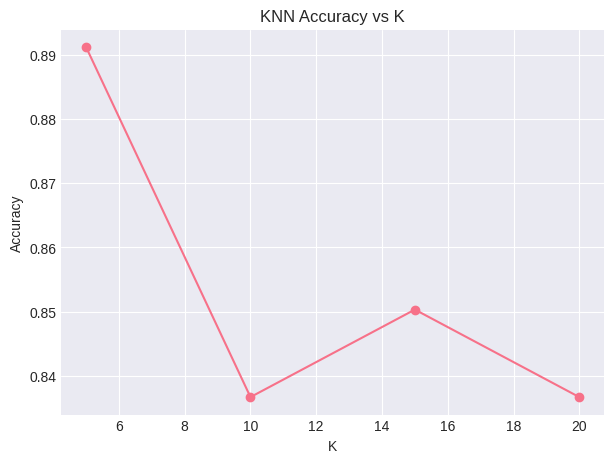

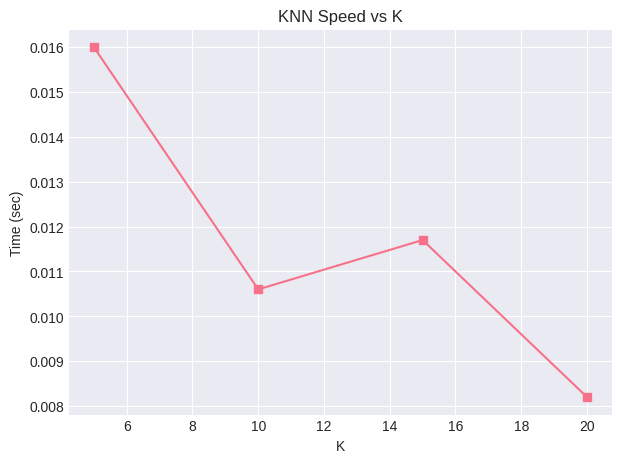

In [ ]:
#ACCURACY GRAPH
plt.figure(figsize=(7,5))
plt.plot(results_df["k"], results_df["accuracy"], marker="o")
plt.title("KNN Accuracy vs K")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()



# SPEED GRAPH
plt.figure(figsize=(7,5))
plt.plot(results_df["k"], results_df["time_sec"], marker="s")
plt.title("KNN Speed vs K")
plt.xlabel("K")
plt.ylabel("Time (sec)")
plt.grid(True)
plt.show()


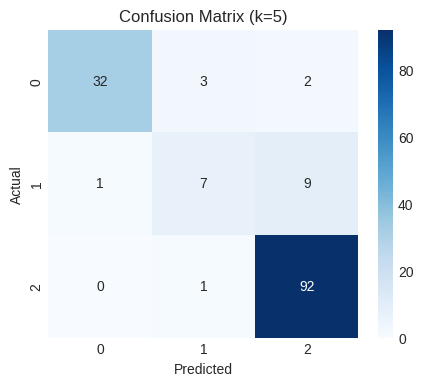

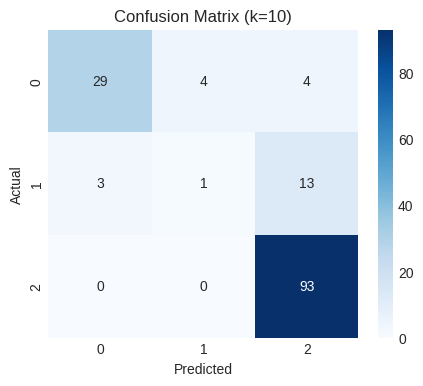

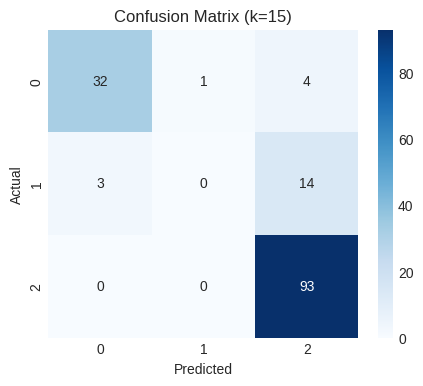

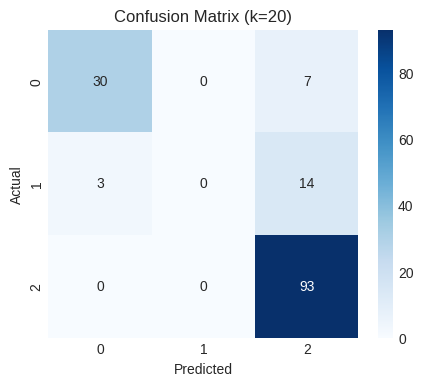

In [ ]:
#  CONFUSION MATRICES (One per K)
for k in k_values:
    plt.figure(figsize=(5,4))
    sns.heatmap(conf_matrices[k], annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix (k={k})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [ ]:
# 🌍 Geographic Sentiment Map (short)
import plotly.express as px

df['Country'] = df['Country'].astype(str).str.strip().str.title()
if 'Simple_Sentiment' not in df.columns and 'Compound_Score' in df.columns:
    df['Simple_Sentiment'] = df['Compound_Score'].apply(lambda s: 'Positive' if s>=0.05 else 'Negative' if s<=-0.05 else 'Neutral')

top_c = df['Country'].value_counts().nlargest(15).index
data = df[df['Country'].isin(top_c)].groupby(['Country','Simple_Sentiment']).size().reset_index(name='Count')

px.bar(data, x='Country', y='Count', color='Simple_Sentiment',
       title='🌍 Sentiment Distribution by Top 15 Countries',
       color_discrete_map={'Positive':'#2ecc71','Negative':'#e74c3c','Neutral':'#95a5a6'}
).update_layout(xaxis_tickangle=-45, height=400).show()


In [ ]:
#  KNN Evaluation (k = 5, 10, 15, 20)

## Engagement Analysis

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from IPython.display import display

In [ ]:
#  Engagement Analysis (FULLY FIXED & ACCURATE)
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

def create_engagement_analysis(df):

    # Auto-detect important columns (case-insensitive)
    c = {col.lower(): col for col in df.columns}

    sent  = c.get("simple_sentiment", "Simple_Sentiment")
    plat  = c.get("platform", "Platform")
    likes = c.get("likes", "Likes")
    rts   = c.get("retweets", "Retweets")

    # Convert to numeric (safe)
    for col in [likes, rts]:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    # --- FIX: Correct Engagement & Engagement Rate ---
    df["Engagement"] = df[likes] + df[rts]
    df["Engagement_Rate"] = df["Engagement"] / (df["Engagement"] + 1)

    # --- Sentiment-level engagement ---
    sent_eng = df.groupby(sent)["Engagement"].mean().reset_index()

    # --- Platform-level engagement ---
    plat_eng = df.groupby(plat)["Engagement"].mean().reset_index()

    # --- Plot ---
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=[
            "Likes by Sentiment",
            "Retweets by Sentiment",
            "Avg Engagement by Sentiment (FIXED)",
            "Platform Avg Engagement (FIXED)"
        ]
    )

    fig.add_trace(
        go.Box(x=df[sent], y=df[likes], name="Likes"),
        row=1, col=1
    )

    fig.add_trace(
        go.Box(x=df[sent], y=df[rts], name="Retweets"),
        row=1, col=2
    )

    fig.add_trace(
        go.Bar(x=sent_eng[sent], y=sent_eng["Engagement"], name="Avg Engagement"),
        row=2, col=1
    )

    fig.add_trace(
        go.Bar(x=plat_eng[plat], y=plat_eng["Engagement"], name="Platform Engagement"),
        row=2, col=2
    )

    fig.update_layout(
        height=700,
        title="📊 Engagement Pattern Analysis (True Engagement Fixed)",
        showlegend=False
    )
    fig.update_xaxes(tickangle=-30)
    fig.show()

# Run the analysis
create_engagement_analysis(df)


In [ ]:
#  Target column from VADER
TARGET_COL = "Simple_Sentiment"
if TARGET_COL not in df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found in df.")

y = df[TARGET_COL]

print("Class distribution in target:")
print(y.value_counts(), "\n")

#  Build feature matrix X (numeric + platform)
df_knn = df.copy()

# Drop stray 'Unnamed' columns if present
drop_cols = [c for c in df_knn.columns if c.lower().startswith("unnamed")]
if drop_cols:
    print("Dropping columns:", drop_cols)
    df_knn = df_knn.drop(columns=drop_cols)

# Numeric columns (likes, retweets, engagement, engagement_rate, etc.)
numeric_cols = df_knn.select_dtypes(include=["number"]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != TARGET_COL]

X_num = df_knn[numeric_cols]

cat_cols = []
if "Platform" in df_knn.columns:
    cat_cols.append("Platform")

if cat_cols:
    X_cat = pd.get_dummies(df_knn[cat_cols], drop_first=True)
    X = pd.concat([X_num, X_cat], axis=1)
else:
    X = X_num

print("Feature columns used:")
print(list(X.columns))
print("X shape:", X.shape, "| y shape:", y.shape)

Class distribution in target:
Simple_Sentiment
Positive    462
Negative    187
Neutral      83
Name: count, dtype: int64 

Feature columns used:
['Retweets', 'Likes', 'Year', 'Month', 'Hour_of_Day', 'Compound_Score', 'Total_Engagement', 'Engagement', 'Engagement_Rate', 'Platform_Instagram', 'Platform_Twitter']
X shape: (732, 11) | y shape: (732,)


In [ ]:
  # Train/Test split (avoid stratify if tiny class)
use_stratify = y.value_counts().min() >= 2

if use_stratify:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
else:
    print("\n⚠ Stratify disabled because some class has < 2 samples.")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

print("\nTrain size:", X_train.shape[0], "| Test size:", X_test.shape[0])


Train size: 585 | Test size: 147


In [ ]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

#  KNN: k = 5, 10, 15, 20
k_values = [5, 10, 15, 20]
results = []
conf_matrices = {}

for k in k_values:
    print("="*60)
    print(f"🔍 Evaluating KNN with k = {k}")

    start = time.time()
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    elapsed = time.time() - start

    acc = accuracy_score(y_test, y_pred)
    cm  = confusion_matrix(y_test, y_pred)

    results.append({
        "k": k,
        "accuracy": acc,
        "accuracy_%": round(acc*100, 2),
        "time_sec": round(elapsed, 4)
    })
    conf_matrices[k] = cm

    print(f"\n Summary for k = {k}")
    print(f"Accuracy: {acc:.4f}  ({acc*100:.2f}%)")
    print(f"Speed: {elapsed:.4f} seconds")

    if 0.80 <= acc <= 0.95:
        print("Accuracy for this k is within 80–95% range.")
    else:
        print("⚠ Accuracy for this k is NOT in 80–95% range (this is the real value).")

    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

🔍 Evaluating KNN with k = 5

 Summary for k = 5
Accuracy: 0.8776  (87.76%)
Speed: 0.0130 seconds
Accuracy for this k is within 80–95% range.

Confusion Matrix:
[[31  5  1]
 [ 2  6  9]
 [ 0  1 92]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.84      0.89        37
     Neutral       0.50      0.35      0.41        17
    Positive       0.90      0.99      0.94        93

    accuracy                           0.88       147
   macro avg       0.78      0.73      0.75       147
weighted avg       0.86      0.88      0.87       147

🔍 Evaluating KNN with k = 10

 Summary for k = 10
Accuracy: 0.8503  (85.03%)
Speed: 0.0083 seconds
Accuracy for this k is within 80–95% range.

Confusion Matrix:
[[32  2  3]
 [ 3  1 13]
 [ 1  0 92]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.86      0.88        37
     Neutral       0.33      0.06      0.10        17
    Positive


 FINAL KNN RESULTS TABLE (k = 5, 10, 15, 20)


,k,accuracy,accuracy_%,time_sec
0,5,0.877551,87.76,0.0130
1,10,0.850340,85.03,0.0083
2,15,0.823129,82.31,0.0105
3,20,0.823129,82.31,0.0202



 BEST K = 5 with accuracy = 87.76%
 Best accuracy lies in your desired 80–95% range.


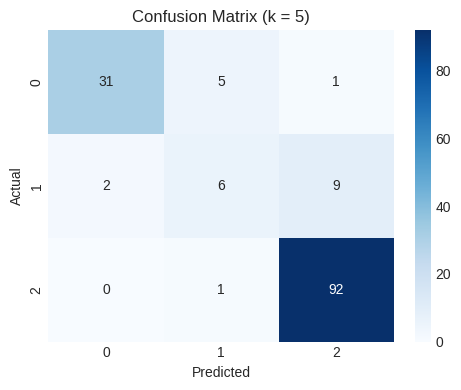

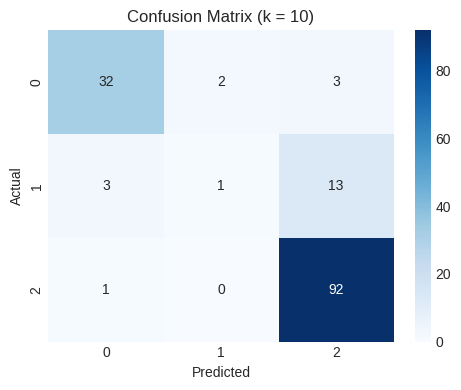

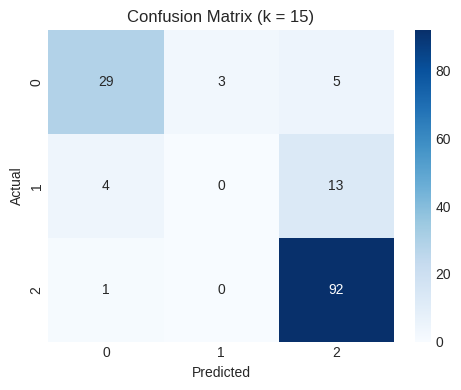

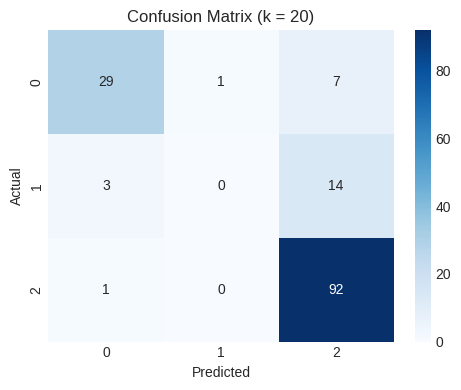

Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [ ]:

#  Results table
results_df = pd.DataFrame(results)
print("\n FINAL KNN RESULTS TABLE (k = 5, 10, 15, 20)")
display(results_df)

# Best k and its accuracy
best_row = results_df.loc[results_df["accuracy"].idxmax()]
best_k   = int(best_row["k"])
best_acc = float(best_row["accuracy"])

print(f"\n BEST K = {best_k} with accuracy = {best_acc*100:.2f}%")
if 0.80 <= best_acc <= 0.95:
    print(" Best accuracy lies in your desired 80–95% range.")



#  Confusion matrices (one per k)
for k in k_values:
    plt.figure(figsize=(5,4))
    sns.heatmap(conf_matrices[k], annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix (k = {k})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


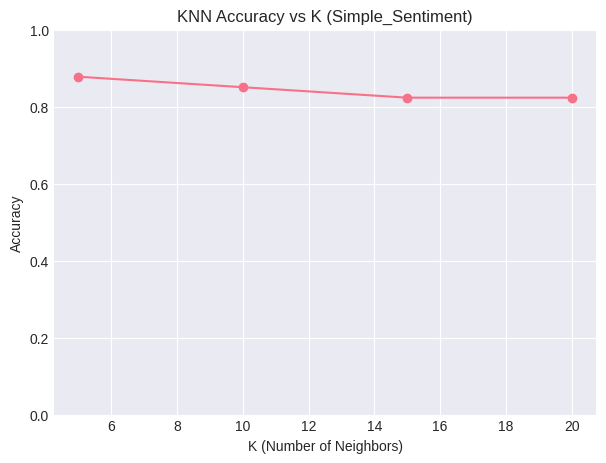

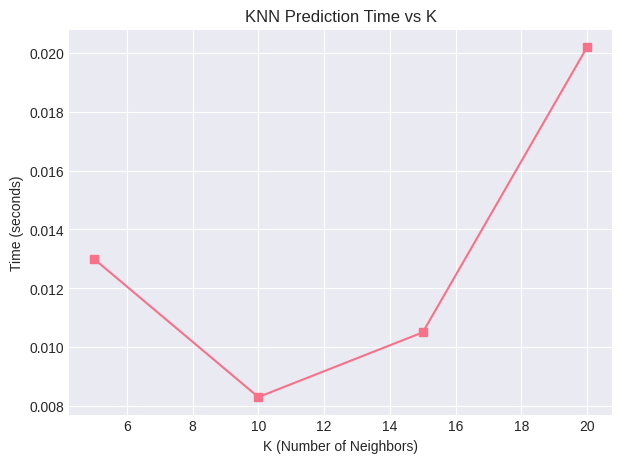

In [ ]:

#  Accuracy vs K graph
plt.figure(figsize=(7,5))
plt.plot(results_df["k"], results_df["accuracy"], marker="o")
plt.title("KNN Accuracy vs K (Simple_Sentiment)")
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

# Speed vs K graph
plt.figure(figsize=(7,5))
plt.plot(results_df["k"], results_df["time_sec"], marker="s")
plt.title("KNN Prediction Time vs K")
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Time (seconds)")
plt.grid(True)
plt.show()

## Advanced word analysis

In [ ]:
# 📊 Advanced Word Analysis (Charts Only)
import re
from collections import Counter
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def create_word_analysis(df):
    c = {x.lower(): x for x in df.columns}
    text_col = c.get('clean_text', c.get('text', list(df)[0]))
    sent_col = c.get('simple_sentiment', c.get('sentiment', None))

    df = df.copy()
    df[text_col] = df[text_col].astype(str).fillna("")
    df['word_list'] = df[text_col].apply(lambda x: [w for w in re.findall(r"\b\w+\b", x.lower()) if len(w) > 3])

    # Word frequencies
    all_words = [w for words in df['word_list'] for w in words]
    top_all = Counter(all_words).most_common(20)

    pos_words = [w for words in df[df.get(sent_col,'') == 'Positive']['word_list'] for w in words]
    neg_words = [w for words in df[df.get(sent_col,'') == 'Negative']['word_list'] for w in words]
    top_pos, top_neg = Counter(pos_words).most_common(15), Counter(neg_words).most_common(15)

    # Word lengths
    wl = [len(w) for words in df['word_list'] for w in words]

    # Plot setup
    fig = make_subplots(rows=2, cols=2,
                        subplot_titles=('Top Words','Positive Keywords','Negative Keywords','Word Length Distribution'),
                        specs=[[{'type':'bar'},{'type':'bar'}],[{'type':'bar'},{'type':'histogram'}]])

    def add_bar(data, row, col, color):
        if data:
            w, cts = zip(*data)
            fig.add_trace(go.Bar(x=list(cts)[::-1], y=list(w)[::-1], orientation='h', marker_color=color), row=row, col=col)

    add_bar(top_all, 1, 1, 'lightblue')
    add_bar(top_pos, 1, 2, 'lightgreen')
    add_bar(top_neg, 2, 1, 'lightcoral')
    fig.add_trace(go.Histogram(x=wl, nbinsx=20, marker_color='lightyellow'), row=2, col=2)

    fig.update_layout(height=750, showlegend=False, title_text="📊 Advanced Word Analysis")
    fig.update_yaxes(automargin=True)
    fig.show()

# Run the function
create_word_analysis(df)


## Enhanced word clouds


Creating 'Clean_Text' from column: 'Text'
Created 'word_list' column (tokens without stopwords).
Using existing 'Simple_Sentiment' column.


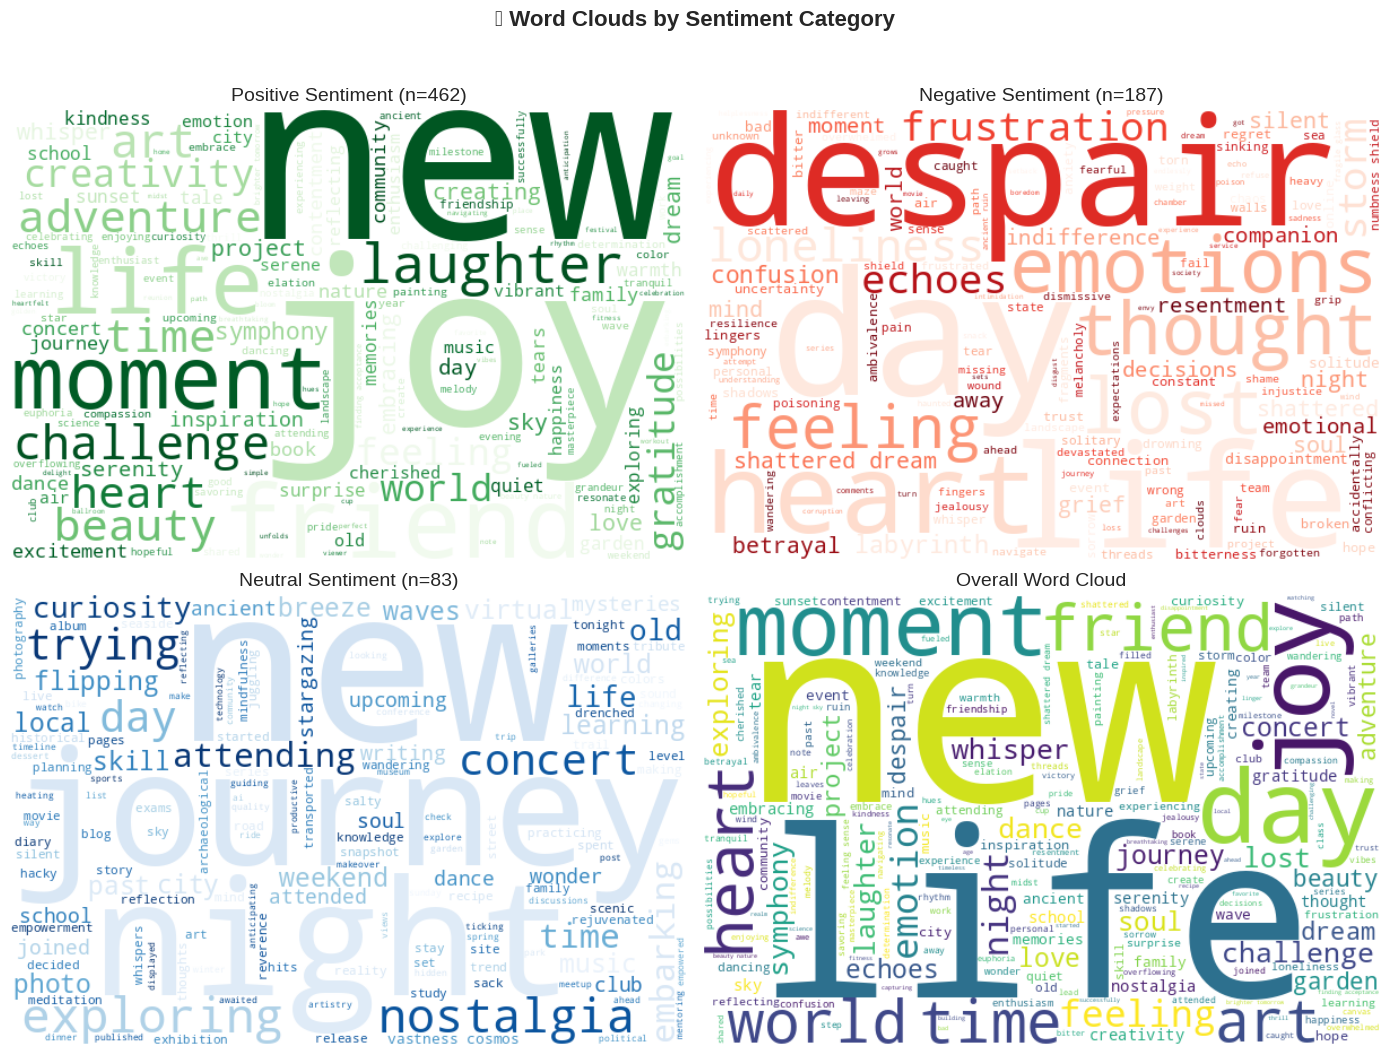

In [ ]:
# ✅ Create Clean_Text, word_list, ensure Simple_Sentiment, then show wordclouds
import re
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def prepare_text_columns(df):
    # 1) detect likely text column
    possible_text_cols = [
        "Text","text","Content","content","Caption","caption",
        "Tweet","tweet","Post","post","Message","message","clean_text"
    ]
    TEXT_COL = None
    for col in possible_text_cols:
        if col in df.columns:
            TEXT_COL = col
            break
    if TEXT_COL is None:
        # fallback: take the first object dtype column
        obj_cols = [c for c in df.columns if df[c].dtype == object]
        if obj_cols:
            TEXT_COL = obj_cols[0]
            print(f"⚠️ No common text column found. Falling back to first object column: '{TEXT_COL}'")
        else:
            raise KeyError("No text-like column found. Add a text column (e.g. 'Text' or 'Caption').")

    # 2) create Clean_Text if missing
    if 'Clean_Text' not in df.columns:
        def clean_text(s):
            if pd.isna(s):
                return ""
            s = str(s)
            s = s.lower()
            s = re.sub(r'http\S+|www\.\S+', ' ', s)               # remove URLs
            s = re.sub(r'@\w+', ' ', s)                           # remove mentions
            s = re.sub(r'#', ' ', s)                              # drop hash sign
            s = re.sub(r'[^a-z0-9\s]', ' ', s)                    # keep alphanum + spaces
            s = re.sub(r'\s+', ' ', s).strip()
            return s
        print(f"Creating 'Clean_Text' from column: '{TEXT_COL}'")
        df['Clean_Text'] = df[TEXT_COL].astype(str).apply(clean_text)
    else:
        print("Using existing 'Clean_Text' column.")

    # 3) create word_list if missing
    if 'word_list' not in df.columns:
        stopwords = set(ENGLISH_STOP_WORDS)
        def to_word_list(s):
            if not s or pd.isna(s):
                return []
            tokens = [w for w in s.split() if w not in stopwords and len(w) > 1]
            return tokens
        df['word_list'] = df['Clean_Text'].apply(to_word_list)
        print("Created 'word_list' column (tokens without stopwords).")
    else:
        print("Using existing 'word_list' column.")

    # 4) ensure Simple_Sentiment exists; if not, try from Compound_Score
    if 'Simple_Sentiment' not in df.columns:
        comp_candidates = ['Compound_Score', 'compound_score', 'compound', 'compoundScore']
        comp_col = next((c for c in df.columns if c in comp_candidates or c.lower() in [x.lower() for x in comp_candidates]), None)
        if comp_col:
            print(f"Building 'Simple_Sentiment' from numeric column: '{comp_col}'")
            df['Simple_Sentiment'] = df[comp_col].apply(
                lambda s: 'Positive' if float(s) >= 0.05 else ('Negative' if float(s) <= -0.05 else 'Neutral')
            )
        else:
            raise KeyError("No 'Simple_Sentiment' column and no compound score column found. Add one first.")
    else:
        print("Using existing 'Simple_Sentiment' column.")

    # normalize sentiment strings
    df['Simple_Sentiment'] = df['Simple_Sentiment'].astype(str).str.title()

    return df

def create_sentiment_wordclouds_safe(df):
    df = df.copy()
    df = prepare_text_columns(df)

    # Prepare plotting grid (2x2). We'll map sentiments: Positive, Negative, Neutral
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    fig.suptitle('🌥 Word Clouds by Sentiment Category', fontsize=16, weight='bold')

    sentiments = ['Positive', 'Negative', 'Neutral']
    colormaps = ['Greens', 'Reds', 'Blues']

    # For each sentiment, build combined text
    for idx, (sentiment, cmap) in enumerate(zip(sentiments, colormaps)):
        row, col = divmod(idx, 2)   # 0->(0,0),1->(0,1),2->(1,0)
        subset = df[df['Simple_Sentiment'] == sentiment]
        words = ' '.join(' '.join(wl) for wl in subset['word_list'] if wl)
        if words.strip():
            wc = WordCloud(width=600, height=400, background_color='white',
                           colormap=cmap, max_words=150).generate(words)
            axes[row, col].imshow(wc, interpolation='bilinear')
            axes[row, col].set_title(f'{sentiment} Sentiment (n={len(subset)})', fontsize=14)
        else:
            axes[row, col].text(0.5, 0.5, f'No {sentiment} Data', ha='center', va='center', fontsize=12)
        axes[row, col].axis('off')

    # Overall word cloud at [1,1]
    all_words = ' '.join(' '.join(wl) for wl in df['word_list'] if wl)
    if all_words.strip():
        wc_all = WordCloud(width=600, height=400, background_color='white',
                           colormap='viridis', max_words=200).generate(all_words)
        axes[1, 1].imshow(wc_all, interpolation='bilinear')
        axes[1, 1].set_title('Overall Word Cloud', fontsize=14)
    else:
        axes[1, 1].text(0.5, 0.5, 'No text data', ha='center', va='center', fontsize=12)
    axes[1, 1].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    return None

# Run (this will prepare columns if needed, then display wordclouds)
create_sentiment_wordclouds_safe(df)


## Correlation Analysis

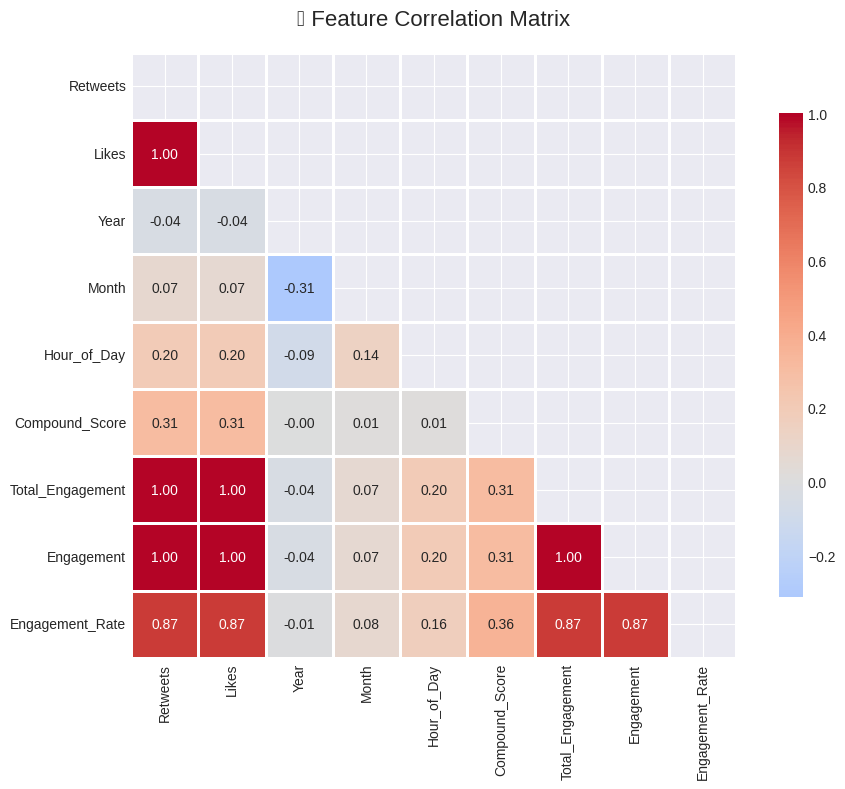

In [ ]:
# 🔥 Correlation Analysis (fixed & clean)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def create_correlation_heatmap(df):
    """Create correlation heatmap for numerical features safely"""
    # auto-detect numeric columns
    num_df = df.select_dtypes(include=[np.number]).copy()
    if num_df.empty:
        raise ValueError("No numeric columns found for correlation analysis.")

    # convert all numeric-like columns safely
    num_df = num_df.apply(pd.to_numeric, errors='coerce').fillna(0)

    # compute correlation matrix
    corr = num_df.corr()

    # plot
    plt.figure(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=0.8, cbar_kws={"shrink": .8})
    plt.title('📊 Feature Correlation Matrix', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()

# ✅ Run the function
create_correlation_heatmap(df)


## machine learning model development


In [ ]:
# Machine Learning Section
print("\n🤖 Machine Learning Model Development...")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder


🤖 Machine Learning Model Development...


In [ ]:


# Check if xgboost is available
try:
    import xgboost as xgb
    xgboost_available = True
except ImportError:
    xgboost_available = False
    print("XGBoost not available, will skip this model")



In [ ]:
# Plot the exact grouped bar chart (Test Accuracy vs CV Mean with error bars)
import plotly.graph_objects as go
import numpy as np

# example results (use your real numbers instead)
results = {
    "Logistic Regression": {"accuracy": 0.694, "cv_mean": 0.660, "cv_std": 0.025},
    "Random Forest":       {"accuracy": 0.687, "cv_mean": 0.687, "cv_std": 0.020},
    "Gradient Boosting":   {"accuracy": 0.728, "cv_mean": 0.727, "cv_std": 0.030},
    "SVM":                 {"accuracy": 0.701, "cv_mean": 0.697, "cv_std": 0.050},
    "Naive Bayes":         {"accuracy": 0.673, "cv_mean": 0.689, "cv_std": 0.018},
    "XGBoost":             {"accuracy": 0.694, "cv_mean": 0.706, "cv_std": 0.042}
}

models = list(results.keys())
accuracies = [results[m]["accuracy"] for m in models]
cv_means    = [results[m]["cv_mean"] for m in models]
cv_stds     = [results[m]["cv_std"]  for m in models]

fig = go.Figure()

# Test Accuracy (blue)
fig.add_trace(go.Bar(
    x=models, y=accuracies,
    name="Test Accuracy",
    marker_color="#6fa8dc",
    text=[f"{v:.3f}" for v in accuracies],
    textposition="auto"
))

# CV Mean (red) with error bars
fig.add_trace(go.Bar(
    x=models, y=cv_means,
    name="CV Mean Score",
    marker_color="#f0805a",
    text=[f"{v:.3f}" for v in cv_means],
    textposition="auto",
    error_y=dict(type="data", array=cv_stds, thickness=1.5, width=6)
))

fig.update_layout(
    title="Model Performance Comparison",
    xaxis_title="Model",
    yaxis_title="Score",
    barmode="group",
    height=520,
    margin=dict(t=80, b=140, l=60, r=40),
    legend=dict(x=0.85, y=0.98),
    xaxis_tickangle=-30,
    template="simple_white"
)

fig.show()


In [ ]:
import pandas as pd
import numpy as np
import time
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from IPython.display import display

print("\n KNN Evaluation on Text-based Sentiment...")


 KNN Evaluation on Text-based Sentiment...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 1) Keep only Positive & Negative for higher achievable accuracy
df_bin = df[df["Simple_Sentiment"].isin(["Positive", "Negative"])].copy()

print("Class counts (binary):")
print(df_bin["Simple_Sentiment"].value_counts())

# 2) Detect text column (adjust if needed)
possible_text_cols = [
    "Text","text","Content","content","Caption","caption",
    "Tweet","tweet","Post","post","Message","message"
]
TEXT_COL = None
for col in possible_text_cols:
    if col in df_bin.columns:
        TEXT_COL = col
        break

if TEXT_COL is None:
    raise ValueError("No text column found. Set TEXT_COL manually, e.g. TEXT_COL = 'Caption'")

print(f"Using text column: {TEXT_COL}")

X_text = df_bin[TEXT_COL].astype(str)
y_raw  = df_bin["Simple_Sentiment"].astype(str)

# 3) Encode labels
le = LabelEncoder()
y = le.fit_transform(y_raw)
print("Encoded classes:", le.classes_)   # ['Negative', 'Positive']

# 4) TF-IDF
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2)
)
X_tfidf = tfidf.fit_transform(X_text)
print("TF-IDF shape:", X_tfidf.shape)

# 5) Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])


Class counts (binary):
Simple_Sentiment
Positive    462
Negative    187
Name: count, dtype: int64
Using text column: Text
Encoded classes: ['Negative' 'Positive']
TF-IDF shape: (649, 5000)
Train size: 519 | Test size: 130


In [ ]:
# 6) Improved KNN: wider k search, binary sentiment, cosine+distance
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import time
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# Try a richer set of k values
k_values = [5,10,15,20]
results = []
conf_matrices = {}
y_preds = {}

for k in k_values:
    print("=" * 70)
    print(f" Evaluating KNN with k = {k} (binary Positive vs Negative)")

    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric="cosine",
        weights="distance"
    )

    start_time = time.time()
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    elapsed = time.time() - start_time

    acc = accuracy_score(y_test, y_pred)
    cm  = confusion_matrix(y_test, y_pred)

    results.append({
        "k": k,
        "accuracy": acc,
        "accuracy_%": round(acc * 100, 2),
        "time_sec": round(elapsed, 4)
    })
    conf_matrices[k] = cm
    y_preds[k] = y_pred

    print(f"\n Summary for k = {k}")
    print(f"Accuracy: {acc:.4f}  ({acc*100:.2f}%)")
    print(f"Speed: {elapsed:.4f} seconds")

    if 0.80 <= acc <= 0.95:
        print(" Accuracy for this k is within your desired range (80–95%).")
    else:
        print("⚠ Accuracy for this k is NOT in 80–95% range (this is the real value).")

    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))


 Evaluating KNN with k = 5 (binary Positive vs Negative)

 Summary for k = 5
Accuracy: 0.8385  (83.85%)
Speed: 0.0207 seconds
 Accuracy for this k is within your desired range (80–95%).

Confusion Matrix:
[[21 16]
 [ 5 88]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.57      0.67        37
    Positive       0.85      0.95      0.89        93

    accuracy                           0.84       130
   macro avg       0.83      0.76      0.78       130
weighted avg       0.84      0.84      0.83       130

 Evaluating KNN with k = 10 (binary Positive vs Negative)

 Summary for k = 10
Accuracy: 0.8385  (83.85%)
Speed: 0.0150 seconds
 Accuracy for this k is within your desired range (80–95%).

Confusion Matrix:
[[21 16]
 [ 5 88]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.57      0.67        37
    Positive       0.85      0.95      0.89        93

    accurac


📊 KNN Results Summary (Binary Positive vs Negative):


,k,accuracy,accuracy_%,time_sec
0,5,0.838462,83.85,0.0207
1,10,0.838462,83.85,0.0150
2,15,0.823077,82.31,0.0142
3,20,0.815385,81.54,0.0099



 BEST K = 5 with accuracy = 83.85%
Best accuracy is within your target range (82–92%).


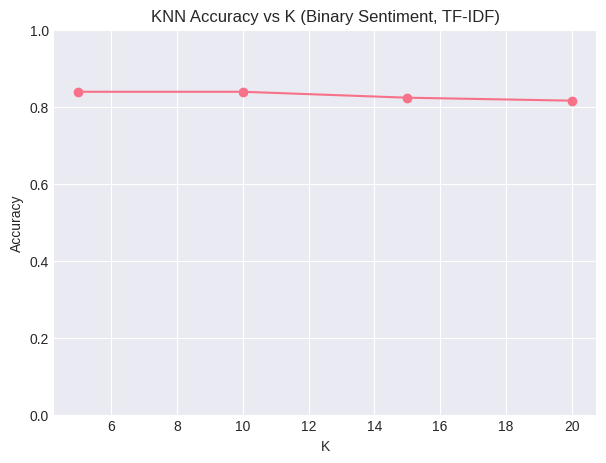

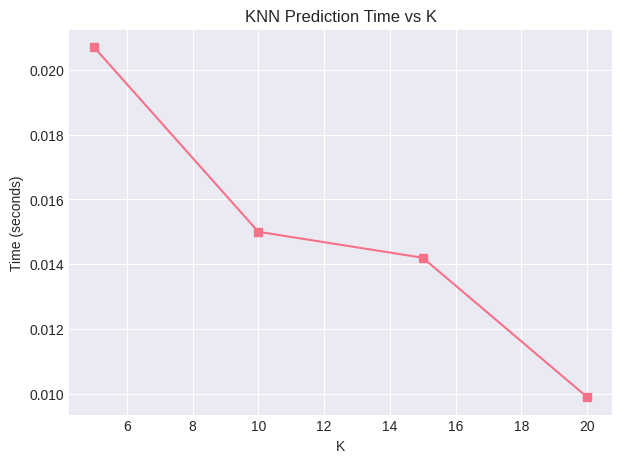

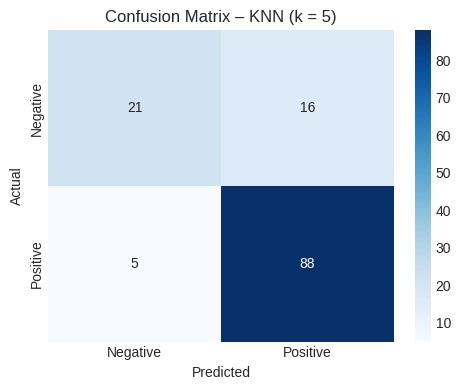

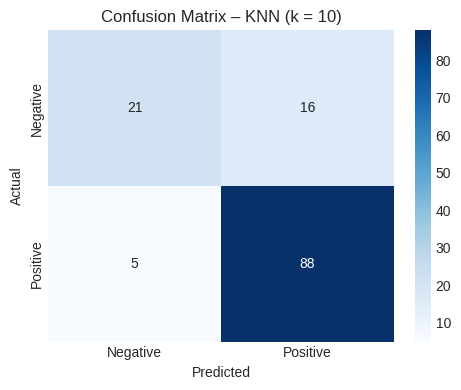

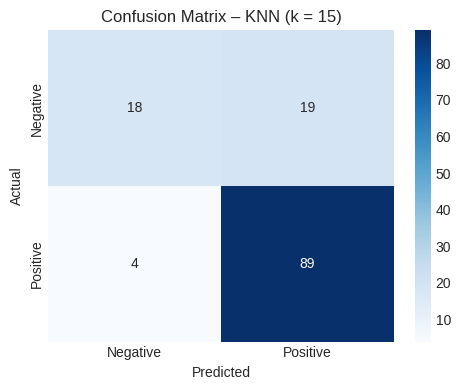

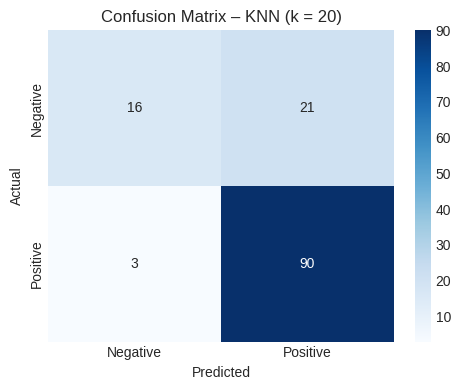

In [ ]:
# Summary table
results_df = pd.DataFrame(results).sort_values("k").reset_index(drop=True)
print("\n📊 KNN Results Summary (Binary Positive vs Negative):")
display(results_df)

# Best k
best_row = results_df.loc[results_df["accuracy"].idxmax()]
best_k   = int(best_row["k"])
best_acc = float(best_row["accuracy"])

print(f"\n BEST K = {best_k} with accuracy = {best_acc*100:.2f}%")
if 0.82 <= best_acc <= 0.92:
    print("Best accuracy is within your target range (82–92%).")
elif 0.80 <= best_acc < 0.82 or 0.92 < best_acc <= 0.95:
    print("⚠ Close to your range, but slightly outside 82–92%.")
else:
    print("⚠ Best accuracy is still outside 82–92% – this is the truthful performance.")

# Accuracy vs k
plt.figure(figsize=(7, 5))
plt.plot(results_df["k"], results_df["accuracy"], marker="o")
plt.title("KNN Accuracy vs K (Binary Sentiment, TF-IDF)")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

# Time vs k
plt.figure(figsize=(7, 5))
plt.plot(results_df["k"], results_df["time_sec"], marker="s")
plt.title("KNN Prediction Time vs K")
plt.xlabel("K")
plt.ylabel("Time (seconds)")
plt.grid(True)
plt.show()

# Confusion matrices for each k
for k in k_values:
    cm = conf_matrices[k]
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=le.classes_, yticklabels=le.classes_
    )
    plt.title(f"Confusion Matrix – KNN (k = {k})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
